In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


from numerical_approximation.chemotaxis import (
    ArcParams,
    ArcPhiParams,
    Endpoint,
    ExternalBC,
    InternalNode,
    arc_mass,
    plot_density_snapshots,
    step_network,
    validate_network,
)

- arc 0: N0 (inlet) -> N1
- arc 1: N1 -> N2
- arc 2: N2 -> N3
- arc 3: N3 -> N4
- arc 4: N1 -> N5
- arc 5: N2 -> N6
- arc 6: N3 -> N7
- arc 7: N4 -> N8
- arc 8: N5 -> N6
- arc 9: N6 -> N7
- arc 10: N7 -> N8
- arc 11: N5 -> N9
- arc 12: N6 -> N10
- arc 13: N7 -> N11
- arc 14: N8 -> N12
- arc 15: N9 -> N10
- arc 16: N10 -> N11
- arc 17: N11 -> N12
- arc 18: N9 -> N13
- arc 19: N10 -> N14
- arc 20: N11 -> N15
- arc 21: N12 -> N16
- arc 22: N13 -> N14
- arc 23: N14 -> N15
- arc 24: N15 -> N16
- arc 25: N16 -> N17 (outlet)

| Node (p)                         | $\xi_{i,j}$ |
|----------------------------------|-------------|
| 1, 2, 3, 5, 8, 9, 12, 14, 15, 16 | 1/3         |
| 4, 13                            | 1/2         |
| 6, 7, 10, 11                     | 1/4         |

$$
\partial_x \phi_1(0, t) = -1\;\qquad \partial_x \phi_{25}(L_{25}, t) = 1
$$

$$
v_1(0, t) = \frac{2}{1 + u_1(0, t)}\;\qquad  v_{25}(L_{25}, t) = -\frac{2}{1 + u_{25}(L_{25}, t)}
$$

For all $i$, we have $\phi_i(x, 0) = 0$.

In [2]:
h_grid = 0.01
T = 60

n_edges = 26
# 1-based in the paper -> 0-based here. The short arcs form the shortest
# inlet -> outlet path: N0 -> N1 -> N5 -> N6 -> N7 -> N11 -> N15 -> N16 -> N17
short_arcs = [i - 1 for i in [1, 5, 9, 10, 14, 21, 25, 26]]
L = [0.5 if i in short_arcs else 10 for i in range(n_edges)]
D = [1 for _ in range(n_edges)]
a = [1 for _ in range(n_edges)]
b = [0.1 for _ in range(n_edges)]
lam = math.sqrt(0.33)
chi = 1
_kappa = 1.0 # All the kappas are the same

# The scheme assumes the CFL condition with equality, h_i = 2*k*lam, on every
# arc. With one lam that means one h for all arcs, so every L_i must be a
# whole multiple of h_grid, and each arc gets its own M_i = L_i/h_grid - 1.
M = [round(L[i] / h_grid) - 1 for i in range(n_edges)]
assert all(math.isclose((M[i] + 1) * h_grid, L[i]) for i in range(n_edges)), "every L_i must be a multiple of h_grid"
h = [h_grid for _ in range(n_edges)]
k = h_grid / (2 * lam)
n_time_steps = round(T / k) + 1

arc_params = {i: ArcParams(lam=lam, h=h[i], k=k, chi=chi) for i in range(n_edges)}
phi_arc_params = {i: ArcPhiParams(D=D[i], a=a[i], b=b[i], h=h[i], k=k, M=M[i]) for i in range(n_edges)}

u_minus = {i: np.zeros((n_time_steps, M[i] + 2)) for i in range(n_edges)}
u_plus = {i: np.zeros((n_time_steps, M[i] + 2)) for i in range(n_edges)}
phi = {i: np.zeros((n_time_steps, M[i] + 2)) for i in range(n_edges)}

distribution_range = (0.45, 0.55)
rng = np.random.default_rng()
for i in range(n_edges):
    u0 = rng.uniform(distribution_range[0], distribution_range[1], size=M[i] + 2)
    u_minus[i][0, :] = u0 / 2
    u_plus[i][0, :] = u0 / 2

Set up the boundary conditions

In [3]:
# Each arc as (node at its j=0 end, node at its j=M+1 end), as in the list above.
# N0 (inlet) and N17 (outlet) are external ends; N1..N16 are internal nodes.
arc_nodes = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (1, 5), (2, 6), (3, 7), (4, 8),
    (5, 6), (6, 7), (7, 8),
    (5, 9), (6, 10), (7, 11), (8, 12),
    (9, 10), (10, 11), (11, 12),
    (9, 13), (10, 14), (11, 15), (12, 16),
    (13, 14), (14, 15), (15, 16),
    (16, 17),
]
assert len(arc_nodes) == n_edges

# Endpoints meeting at each internal node N1..N16.
# "left" is j=0, "right" is j=M+1
node_endpoints = {f"N{p}": [] for p in range(1, 17)}
for arc, (tail, head) in enumerate(arc_nodes):
    if f"N{tail}" in node_endpoints:
        node_endpoints[f"N{tail}"].append(Endpoint(arc, "left"))
    if f"N{head}" in node_endpoints:
        node_endpoints[f"N{head}"].append(Endpoint(arc, "right"))

# kappa (phi coupling) and xi (u/v coupling) are scoped to each node and
# keyed by the arcs meeting there; xi also needs the (i, i) self-pairs.
# xi = 1 / (number of arcs at the node) reproduces the table above.
internal_nodes = []
for endpoints in node_endpoints.values():
    arcs = [ep.arc for ep in endpoints]
    internal_nodes.append(InternalNode(
        endpoints=endpoints,
        kappa={(i, j): _kappa for i in arcs for j in arcs if i != j},
        xi={(i, j): 1 / len(arcs) for i in arcs for j in arcs},
    ))

# External ends: food at the inlet and the outlet
external_bcs = [
    ExternalBC(Endpoint(0, "left"), kind="flux", phibar=-1.0),   # phi_x(0,t) = -1 on the inlet arc
    ExternalBC(Endpoint(25, "right"), kind="flux", phibar=1.0),  # phi_x(L,t) = 1 on the outlet arc
]

# u/v boundary kind at the external ends only.
# food_source imposes v = 2/(1+u) at j=0 and food_sink imposes v = -2/(1+u)
# at j=M+1, i.e. both push organism INTO the network (v > 0 is rightward).
bc_type = {
    (0, "left"): "food_source",
    (25, "right"): "food_sink",
}

validate_network(arc_params, bc_type, external_bcs, internal_nodes)

Solve the system

In [4]:
record_every = 5
t_history = []
mass_history = {i: [] for i in range(n_edges)}

for n in range(n_time_steps - 1):
    if n % record_every == 0:
        t_history.append(n * k)
        for i in range(n_edges):
            mass_history[i].append(arc_mass(u_minus[i][n], u_plus[i][n], h[i]))

    step_network(
        u_minus, u_plus, phi, n,
        arc_params, phi_arc_params, bc_type,
        external_bcs, internal_nodes,
    )

## Density on the graph itself

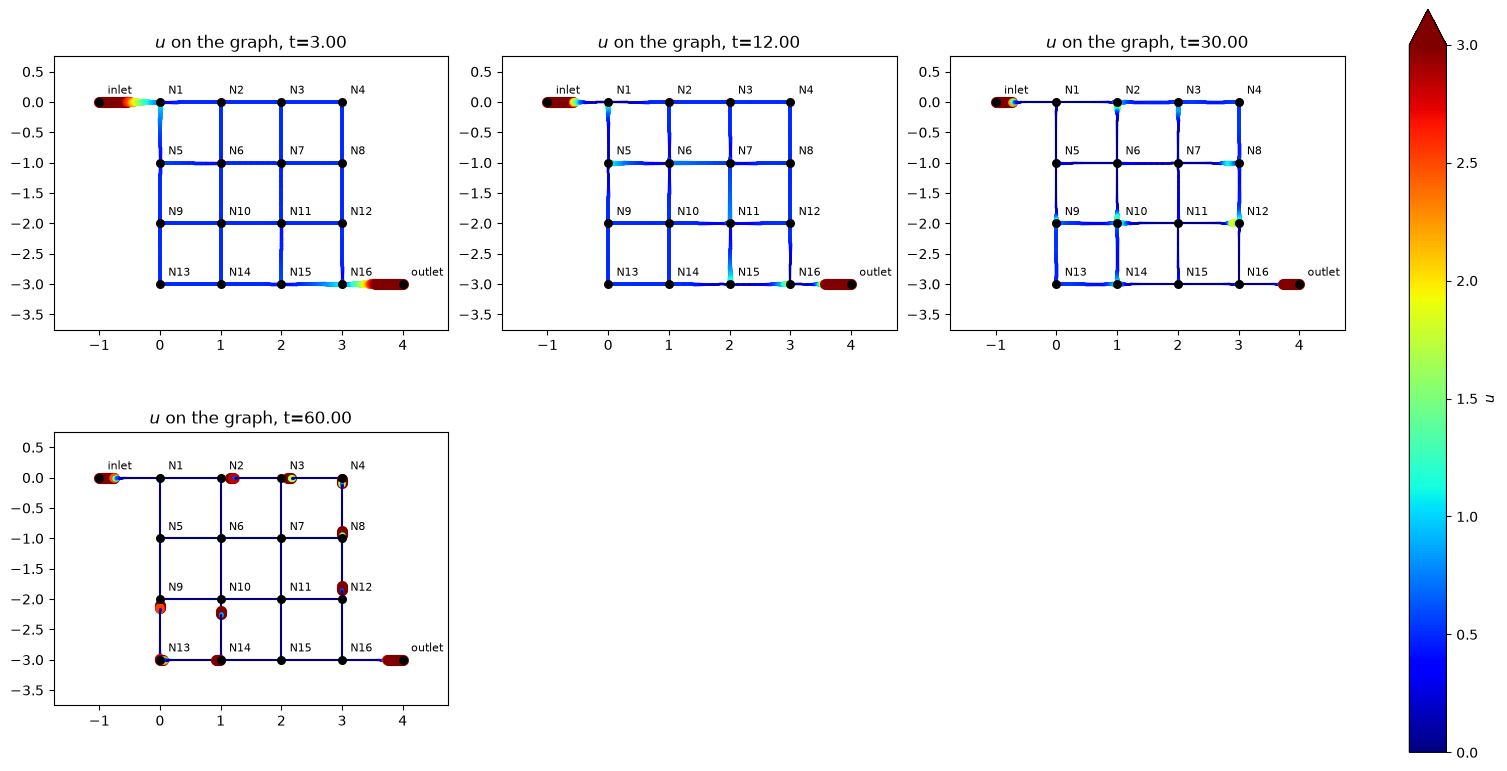

In [5]:
# Positions keyed by internal-node index (N1..N16 -> 0..15) or external end (arc, side).
# N1..N16 sit on a 4x4 grid, row by row from the top left.
node_pos = {p - 1: ((p - 1) % 4, -((p - 1) // 4)) for p in range(1, 17)} | {
    (0, "left"): (-1.0, 0.0),    # N0, inlet
    (25, "right"): (4.0, -3.0),  # N17, outlet
}
node_labels = {p: name for p, name in enumerate(node_endpoints)} | {
    (0, "left"): "inlet",
    (25, "right"): "outlet",
}

snapshot_times = [3, 12, 30, 60]
snapshot_indices = [min(round(t / k), n_time_steps - 1) for t in snapshot_times]

plot_density_snapshots(
    node_pos, internal_nodes, external_bcs, u_minus, u_plus, snapshot_indices, k,
    node_labels=node_labels,
    vmax=3,  # clip to the paper's colour scale; larger u saturates
)
plt.show()